# Laboratorio 7 - Teoría de Probabilidades

## Etapa 1: Simulación básica con álbum reducido

Este notebook implementa los procedimientos solicitados para la etapa 1:

- Parámetros: N = 100, S = 7, R = 10000, semilla 2026.
- Simulación del llenado del álbum usando sobres con estampas distintas dentro del mismo sobre.
- Cálculo de estadísticas pedidas y comparación con teoría del coleccionista.
- Visualización con histograma del número de sobres necesarios.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:

# -------------------------------
# Parámetros de la etapa 1
# -------------------------------
N = 100      # total de estampas diferentes
S = 7        # estampas por sobre (sin repetición dentro del sobre)
R = 10_000   # número de simulaciones
SEED = 2026

np.random.seed(SEED)
universe = np.arange(N)

packs_needed = np.empty(R, dtype=int)
repeated_stickers = np.empty(R, dtype=int)

for r in range(R):
    collected = np.zeros(N, dtype=bool)
    unique_count = 0
    packs = 0
    repeats = 0

    while unique_count < N:
        pack = np.random.choice(universe, size=S, replace=False)
        packs += 1

        new_in_pack = (~collected[pack]).sum()
        repeats += S - new_in_pack

        collected[pack] = True
        unique_count += new_in_pack

    packs_needed[r] = packs
    repeated_stickers[r] = repeats



In [3]:
# -------------------------------
# Resultados empíricos
# -------------------------------
mean_packs = packs_needed.mean()
std_packs = packs_needed.std(ddof=1)
mean_repeats = repeated_stickers.mean()
std_repeats = repeated_stickers.std(ddof=1)
prob_more_than_30 = (packs_needed > 30).mean()

# -------------------------------
# Teoría del coleccionista
# E[T] ≈ (N / S) * H_N
# -------------------------------
H_N_exact = sum(1 / k for k in range(1, N + 1))
H_N_approx = math.log(N) + 0.5772
E_T_theoretical = (N / S) * H_N_exact

# Repetidas teóricas por linealidad de la esperanza:
# E[repetidas] = E[S*T - N] = S*E[T] - N
E_repeats_theoretical = S * E_T_theoretical - N

# Mínimo teórico sin repetidas
min_theoretical_packs = math.ceil(N / S)


In [4]:
print("=== Resultados de simulación (Etapa 1) ===")
print(f"Media de sobres necesarios: {mean_packs:.4f}")
print(f"Desviación estándar de sobres: {std_packs:.4f}")
print(f"Media de estampas repetidas: {mean_repeats:.4f}")
print(f"Desviación estándar de repetidas: {std_repeats:.4f}")
print(f"P(T > 30): {prob_more_than_30:.4f}")

=== Resultados de simulación (Etapa 1) ===
Media de sobres necesarios: 72.2456
Desviación estándar de sobres: 17.4724
Media de estampas repetidas: 405.7192
Desviación estándar de repetidas: 122.3067
P(T > 30): 1.0000


In [5]:
print("=== Referencia teórica ===")
print(f"H_{N} exacto: {H_N_exact:.6f}")
print(f"H_{N} aproximado ln(N)+gamma: {H_N_approx:.6f}")
print(f"E[T] teórico: {E_T_theoretical:.4f}")
print(f"E[repetidas] teórico: {E_repeats_theoretical:.4f}")
print(f"Mínimo teórico de sobres (sin repetidas): {min_theoretical_packs}")
print(f"Mínimo observado en simulaciones: {packs_needed.min()}")

=== Referencia teórica ===
H_100 exacto: 5.187378
H_100 aproximado ln(N)+gamma: 5.182370
E[T] teórico: 74.1054
E[repetidas] teórico: 418.7378
Mínimo teórico de sobres (sin repetidas): 15
Mínimo observado en simulaciones: 37


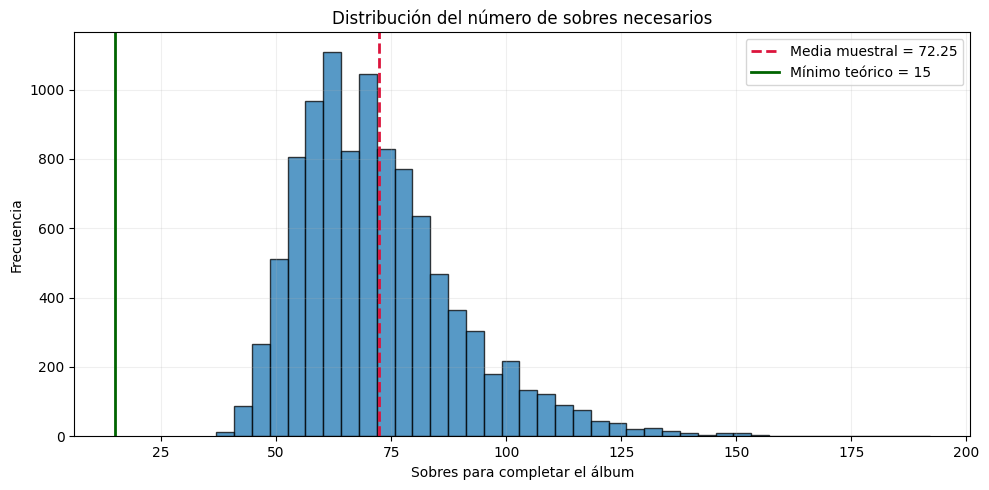

In [6]:
# -------------------------------
# Visualización
# -------------------------------
plt.figure(figsize=(10, 5))
plt.hist(packs_needed, bins=40, edgecolor="black", alpha=0.75)
plt.axvline(mean_packs, color="crimson", linestyle="--", linewidth=2, label=f"Media muestral = {mean_packs:.2f}")
plt.axvline(min_theoretical_packs, color="darkgreen", linestyle="-", linewidth=2, label=f"Mínimo teórico = {min_theoretical_packs}")
plt.title("Distribución del número de sobres necesarios")
plt.xlabel("Sobres para completar el álbum")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Etapa 2: Escenario real del álbum (N = 980)

En esta etapa se simula el álbum real con `N = 980` estampas y `S = 7` estampas por sobre, manteniendo `R = 10000` y semilla `2026`.

Para acelerar la ejecución, se modela cuántas estampas nuevas trae cada sobre con una distribución hipergeométrica (equivalente al muestreo sin reemplazo dentro del sobre).

In [ ]:
# -------------------------------
# Etapa 2: simulación del álbum real
# -------------------------------
N2 = 980
S2 = 7
R2 = 10_000
SEED2 = 2026

rng = np.random.default_rng(SEED2)

packs_needed_980 = np.empty(R2, dtype=int)
repeated_980 = np.empty(R2, dtype=int)

for r in range(R2):
    collected_count = 0
    packs = 0
    repeats = 0

    while collected_count < N2:
        # Número de nuevas en el sobre ~ Hipergeométrica(
        #   ngood = faltantes, nbad = ya obtenidas, nsample = S2
        # )
        new_in_pack = rng.hypergeometric(
            ngood=N2 - collected_count,
            nbad=collected_count,
            nsample=S2,
        )

        collected_count += new_in_pack
        packs += 1
        repeats += S2 - new_in_pack

    packs_needed_980[r] = packs
    repeated_980[r] = repeats

# Métricas empíricas
mean_packs_980 = packs_needed_980.mean()
std_packs_980 = packs_needed_980.std(ddof=1)
mean_repeats_980 = repeated_980.mean()
std_repeats_980 = repeated_980.std(ddof=1)

# Teoría del coleccionista
H_980 = sum(1 / k for k in range(1, N2 + 1))
E_T_980 = (N2 / S2) * H_980
E_rep_980 = S2 * E_T_980 - N2
min_packs_980 = math.ceil(N2 / S2)

# Costos (quetzales)
single_pack_price = 9.50
box_packs = 104
box_price = 975.00

cost_single_only = packs_needed_980 * single_pack_price
cost_boxes_only = np.ceil(packs_needed_980 / box_packs) * box_price
cost_mixed = (
    np.floor(packs_needed_980 / box_packs) * box_price
    + (packs_needed_980 % box_packs) * single_pack_price
)

print("=== Etapa 2: resultados empíricos ===")
print(f"Media de sobres: {mean_packs_980:.4f}")
print(f"Desviación estándar de sobres: {std_packs_980:.4f}")
print(f"Media de repetidas: {mean_repeats_980:.4f}")
print(f"Desviación estándar de repetidas: {std_repeats_980:.4f}")
print(f"Mínimo observado de sobres: {packs_needed_980.min()}")
print()
print("=== Etapa 2: referencia teórica ===")
print(f"H_980 exacto: {H_980:.6f}")
print(f"E[T] teórico: {E_T_980:.4f}")
print(f"E[repetidas] teórico: {E_rep_980:.4f}")
print(f"Mínimo teórico de sobres: {min_packs_980}")
print()
print("=== Costos esperados (Q) ===")
print(f"Solo sobres individuales: {cost_single_only.mean():.2f}")
print(f"Solo cajas de 104 sobres: {cost_boxes_only.mean():.2f}")
print(f"Estrategia mixta (cajas + sobrantes): {cost_mixed.mean():.2f}")
print()
print("=== Probabilidad de completar con presupuesto Q10,000 ===")
print(f"Solo sobres individuales: {(cost_single_only <= 10_000).mean():.4f}")
print(f"Solo cajas: {(cost_boxes_only <= 10_000).mean():.4f}")
print(f"Estrategia mixta: {(cost_mixed <= 10_000).mean():.4f}")

# Histograma de sobres para N=980
plt.figure(figsize=(10, 5))
plt.hist(packs_needed_980, bins=50, edgecolor="black", alpha=0.75)
plt.axvline(mean_packs_980, color="crimson", linestyle="--", linewidth=2, label=f"Media muestral = {mean_packs_980:.1f}")
plt.axvline(min_packs_980, color="darkgreen", linestyle="-", linewidth=2, label=f"Mínimo teórico = {min_packs_980}")
plt.title("Etapa 2: distribución de sobres necesarios (N=980)")
plt.xlabel("Sobres para completar el álbum")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Análisis de resultados (Etapa 2)

1. **Número esperado de sobres (N=980)**
   - Simulación: media `1044.0989` sobres.
   - Teoría del coleccionista: `E[T] = 1045.1390` sobres.
   - Diferencia absoluta: `1.0401` sobres (~`0.10%`), lo cual valida la simulación.

2. **Estampas repetidas**
   - Simulación: media `6328.6923` repetidas.
   - Teórico: `E[repetidas] = 6335.9728`.
   - Diferencia absoluta: `7.2805` (~`0.11%`), también consistente con la teoría.

3. **Variabilidad del proceso**
   - Desviación estándar de sobres: `177.9660`.
   - Coeficiente de variación: `177.9660 / 1044.0989 ≈ 17.04%`.
   - Hay variabilidad significativa: dos personas pueden requerir cantidades de sobres bastante distintas.

4. **Costos esperados**
   - Solo sobres individuales: `Q 9918.94`.
   - Solo cajas de 104 sobres: `Q 10265.09`.
   - Estrategia mixta (cajas completas + sobres sueltos para el remanente): `Q 9794.93`.
   - Con estos supuestos, la estrategia mixta es la más económica en promedio.

5. **Presupuesto de Q10,000**
   - Probabilidad de completar con solo sobres: `0.5879`.
   - Probabilidad con solo cajas: `0.5617`.
   - Probabilidad con estrategia mixta: `0.6178`.
   - Bajo este modelo, la estrategia mixta también maximiza la probabilidad de completar con ese presupuesto.